In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 5

DATA_DIR = "./data/Soil types"

CLASS_NAMES = ["Black Soil", "Cinder Soil", "Laterite Soil", "Peat Soil", "Yellow Soil"]

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
def load_dataset(data_dir, img_size=(224, 224)):
    images = []
    labels = []

    for idx, class_name in enumerate(CLASS_NAMES):
        folder = os.path.join(data_dir, class_name)

        for file in os.listdir(folder):
            path = os.path.join(folder, file)

            img = cv2.imread(path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(idx)

    return np.array(images), np.array(labels)

In [ ]:
X, y = load_dataset(DATA_DIR, IMG_SIZE)

print("Total samples:", len(X))
print("Class distribution:", np.bincount(y))

Total samples: 156
Class distribution: [37 30 30 30 29]


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

y_train = to_categorical(y_train, NUM_CLASSES)
y_val   = to_categorical(y_val, NUM_CLASSES)
y_test  = to_categorical(y_test, NUM_CLASSES)


In [ ]:
def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    return image, label


train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1024).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

In [21]:
def create_model():
    base = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    x = Dropout(0.6)(x)
    x = Dense(128, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    out = Dense(NUM_CLASSES, activation="softmax")(x)

    return Model(inputs=base.input, outputs=out)


model = create_model()

In [22]:
model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

In [23]:
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_densenet.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.1651 - loss: 3.1686 - val_accuracy: 0.2174 - val_loss: 2.1028 - learning_rate: 3.0000e-04
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 756ms/step - accuracy: 0.1743 - loss: 2.6866 - val_accuracy: 0.1739 - val_loss: 1.9758 - learning_rate: 3.0000e-04
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 746ms/step - accuracy: 0.2202 - loss: 2.5966 - val_accuracy: 0.1739 - val_loss: 1.8956 - learning_rate: 3.0000e-04
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 954ms/step - accuracy: 0.2752 - loss: 2.3303 - val_accuracy: 0.4348 - val_loss: 1.8343 - learning_rate: 3.0000e-04
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 743ms/step - accuracy: 0.3119 - loss: 2.1869 - val_accuracy: 0.4348 - val_loss: 1.7890 - learning_rate: 3.0000e-04
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3578 - loss: 1.9499 - val_accuracy: 0.4783 - val_loss: 1.7538 - learning_rate: 3.0000e-04
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 954ms/step - accuracy: 0.3670 - loss: 1.86

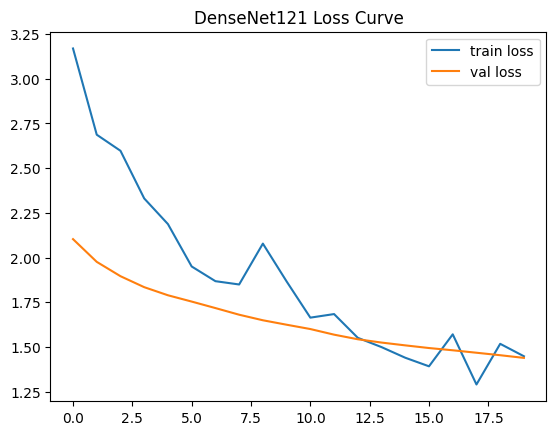

In [25]:
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("DenseNet121 Loss Curve")
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

Test accuracy: 0.25
Test loss: 4.321131706237793


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step


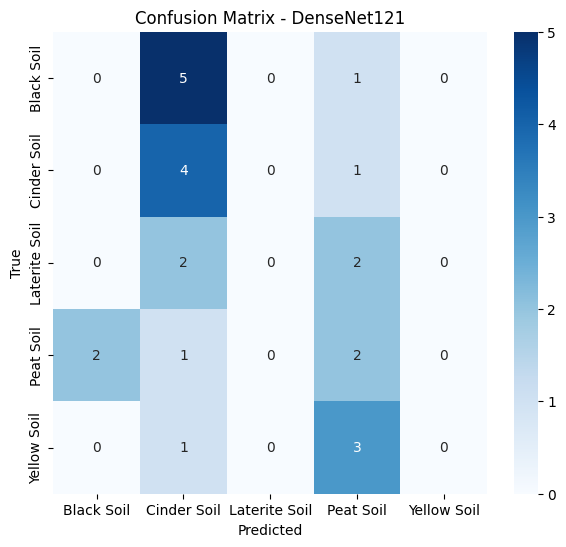

               precision    recall  f1-score   support

   Black Soil       0.00      0.00      0.00         6
  Cinder Soil       0.31      0.80      0.44         5
Laterite Soil       0.00      0.00      0.00         4
    Peat Soil       0.22      0.40      0.29         5
  Yellow Soil       0.00      0.00      0.00         4

     accuracy                           0.25        24
    macro avg       0.11      0.24      0.15        24
 weighted avg       0.11      0.25      0.15        24



c:\Users\Andrei\Desktop\Proiecte A1S2\CV2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Andrei\Desktop\Proiecte A1S2\CV2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Andrei\Desktop\Proiecte A1S2\CV2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix - DenseNet121")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

In [14]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=CLASS_NAMES
))

               precision    recall  f1-score   support

   Black Soil       1.00      0.67      0.80         6
  Cinder Soil       0.50      0.40      0.44         5
Laterite Soil       0.33      0.25      0.29         4
    Peat Soil       0.60      0.60      0.60         5
  Yellow Soil       0.50      1.00      0.67         4

     accuracy                           0.58        24
    macro avg       0.59      0.58      0.56        24
 weighted avg       0.62      0.58      0.58        24

